In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()  # keep the slides quiet

import numpy as np
import matplotlib.pyplot as plt

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from sim_theorem_partii import DispersionBiasExperiment

OUT_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR.mkdir(exist_ok=True)

# Same canonical diagonal-Gram model as theorem_partii_clean_heavy_tail.ipynb.
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},   # market-like factor
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
design = DesignSpec(
    n_values=[60],
    p_values=[200, 500, 1000, 2000, 5000, 10000, 20000],
    n_reps=300,
    random_seed=20260511,
    sampling="nested",
    # Heavy-tail variant: swap in student-t samplers, e.g.
    # factor_return_sampler={"distribution": "student_t", "df": 3, "loc": 0.0, "scale": 1.0},
    # idio_return_sampler={"distribution": "student_t", "df": 4, "loc": 0.0, "scale": 1.0},
)

df = run_experiment(model, design, DispersionBiasExperiment())

# Plot-ready angles, named to the Eq.(17) decomposition  (paper symbol -> column -> here):
#   measured  sin^2 angle(h_j, b_j)              sin2_j  -> ang_meas
#   out-of-subspace + in-subspace (full RHS)     rhs     -> ang_theory
#   out-of-subspace error  d^2/(n*lambda+d^2)    floor   -> ang_oos
#   lambda_{n,j} = eig of D_hat = C^{1/2}(F'F/n)C^{1/2}  (renormalized; c=[2,1,1])  -> column 'rho'
# to_deg maps sin^2 -> angle in degrees.
def to_deg(v):
    """sin^2 of an angle -> the angle in degrees."""
    return np.degrees(np.arcsin(np.sqrt(np.clip(v, 0.0, 1.0))))

d = df.assign(
    s2_meas=df["sin2_j"], s2_theory=df["rhs"], s2_oos=df["floor"],          # additive frame (sin^2)
    ang_meas=to_deg(df["sin2_j"]), ang_theory=to_deg(df["rhs"]), ang_oos=to_deg(df["floor"]),
)
def summarize(frame, key):
    """Per (key, factor j): component means + SEMs of measured/theory and of the paired
    gap (= measured - theory), over the replicate axis. SE = sd/sqrt(n_reps)."""
    g = frame.assign(gap=frame["s2_meas"] - frame["s2_theory"])
    return g.groupby([key, "j"]).agg(
        s2_meas=("s2_meas", "mean"),       s2_meas_se=("s2_meas", "sem"),
        s2_theory=("s2_theory", "mean"),   s2_theory_se=("s2_theory", "sem"),
        s2_oos=("s2_oos", "mean"),
        ang_meas=("ang_meas", "mean"),     ang_meas_se=("ang_meas", "sem"),
        ang_theory=("ang_theory", "mean"), ang_theory_se=("ang_theory", "sem"),
        ang_oos=("ang_oos", "mean"),
        gap=("gap", "mean"),               gap_se=("gap", "sem"),
    ).reset_index()

avg = summarize(d, "p")
P_VALUES = sorted(d["p"].unique())

NAVY, RED, GRAY = "#1f3864", "#c0392b", "#555555"
FACTOR_COLORS = ["tab:blue", "tab:orange", "tab:green"]
DEG_TICKS = ([0, 30, 60, 90], ["0\u00b0", "30\u00b0", "60\u00b0", "90\u00b0"])
print(f"rows: {len(df)}   p sweep: {P_VALUES}")

replicate:   0%|          | 0/300 [00:00<?, ?rep/s]

replicate:   1%|          | 3/300 [00:00<00:19, 15.50rep/s]

replicate:   2%|▏         | 5/300 [00:00<00:22, 13.16rep/s]

replicate:   3%|▎         | 8/300 [00:00<00:16, 18.17rep/s]

replicate:   4%|▍         | 12/300 [00:00<00:12, 23.91rep/s]

...

replicate:  97%|█████████▋| 292/300 [00:08<00:00, 35.51rep/s]

replicate:  99%|█████████▊| 296/300 [00:08<00:00, 35.65rep/s]

replicate: 100%|██████████| 300/300 [00:08<00:00, 35.58rep/s]

replicate: 100%|██████████| 300/300 [00:08<00:00, 33.79rep/s]

rows: 6300   p sweep: [np.int64(200), np.int64(500), np.int64(1000), np.int64(2000), np.int64(5000), np.int64(10000), np.int64(20000)]


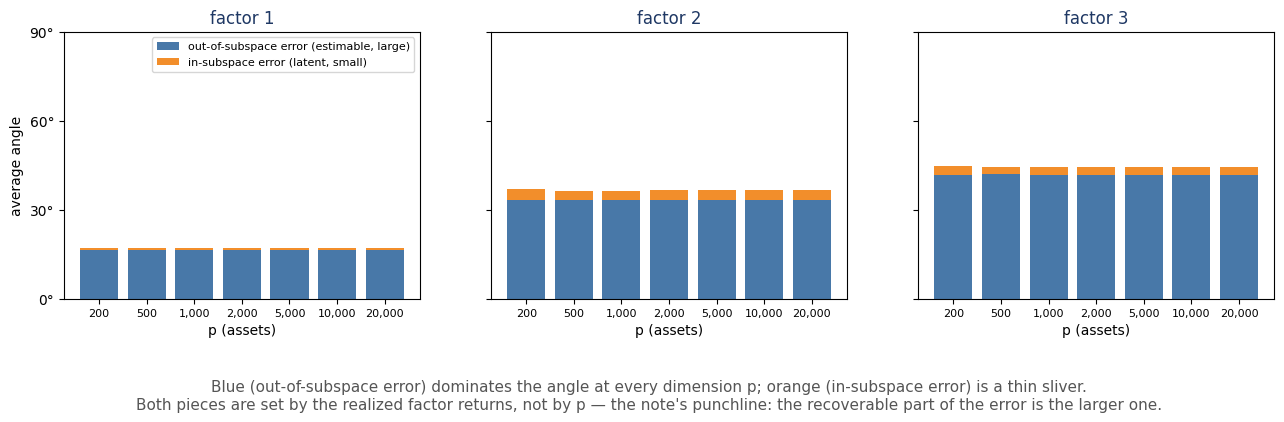

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13.3, 4.6), sharey=True)
fig.subplots_adjust(left=0.06, right=0.97, top=0.86, bottom=0.28)

x = np.arange(len(P_VALUES))
for j, ax in zip((1, 2, 3), axes):
    a = avg[avg["j"] == j].set_index("p").loc[P_VALUES]
    oos_part = a["ang_oos"].to_numpy()
    insub_part = a["ang_theory"].to_numpy() - oos_part
    ax.bar(x, oos_part, color="#4878a8", label="out-of-subspace error (estimable, large)")
    ax.bar(x, insub_part, bottom=oos_part, color="#f28e2b",
           label="in-subspace error (latent, small)")
    ax.set_xticks(x, [f"{p:,}" for p in P_VALUES], fontsize=8)
    ax.set_ylim(0, 90)
    ax.set_yticks(*DEG_TICKS)
    ax.set_title(f"factor {j}", color=NAVY)
    ax.set_xlabel("p (assets)")
axes[0].set_ylabel("average angle")
axes[0].legend(fontsize=8, loc="upper right")

fig.text(0.5, 0.04,
         "Blue (out-of-subspace error) dominates the angle at every dimension p; orange (in-subspace error"
         ") is a thin sliver.\nBoth pieces are set by the realized factor returns, "
         "not by p \u2014 the note's punchline: the recoverable part of the error is the larger one.",
         fontsize=11, color=GRAY, ha="center")

fig.savefig(OUT_DIR / "slide_partii_check_reveals.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
# Plot styling + stacked-decomposition / gap helpers shared by the panels below.
N_FIXED = design.n_values[0]   # n held fixed across the p sweep (= 60)
FACTOR_COLORS = ["tab:blue", "tab:orange", "tab:green"]
NAVY, GRAY = "#1f3864", "#555555"
DEG_TICKS  = ([0, 30, 60, 90], ["0°", "30°", "60°", "90°"])
SIN2_TICKS = ([0, 0.25, 0.5, 0.75, 1.0], ["0", "0.25", "0.50", "0.75", "1.0"])

# Eq. (17): sin^2 angle(h, b) = out-of-subspace + in-subspace  (additive in sin^2).
LABEL_MEAS  = r"measured $\angle(h, \bar b)$"
LABEL_OOS   = r"out-of-subspace error: $\delta^2/(n\lambda_{n,j}+\delta^2)$"
LABEL_INSUB = "in-subspace error"

def decomp_panel(ax, cats, meas, oos, insub, meas_color, meas_se=None, total_se=None, width=0.8):
    """Measured bar beside a theory bar stacked as out-of-subspace + in-subspace.
    Optional 95% CI caps (yerr = 1.96 * SE) on the measured bar and the stack total."""
    x = np.arange(len(cats))
    bw = width / 2
    ax.bar(x - bw / 2, meas,  bw, color=meas_color, label=LABEL_MEAS)
    ax.bar(x + bw / 2, oos,   bw, color="0.78", label=LABEL_OOS)
    ax.bar(x + bw / 2, insub, bw, bottom=oos, color="0.45", label=LABEL_INSUB)
    cap = dict(fmt="none", ecolor="black", elinewidth=0.8, capsize=2)
    if meas_se is not None:
        ax.errorbar(x - bw / 2, meas, yerr=1.96 * meas_se, **cap)
    if total_se is not None:
        ax.errorbar(x + bw / 2, oos + insub, yerr=1.96 * total_se, **cap)
    ax.set_xticks(x, cats, fontsize=8)
    return x

def gap_panel(ax, cats, gap, gap_se, color):
    """Paired residual gap = measured - theory vs x, with 95% CI and a zero reference."""
    x = np.arange(len(cats))
    ax.axhline(0, color="0.6", lw=0.8, ls="--")
    ax.errorbar(x, gap, yerr=1.96 * gap_se, fmt="o-", color=color, ms=4, lw=1.2, capsize=2)
    ax.set_xticks(x, cats, fontsize=8)
    return x

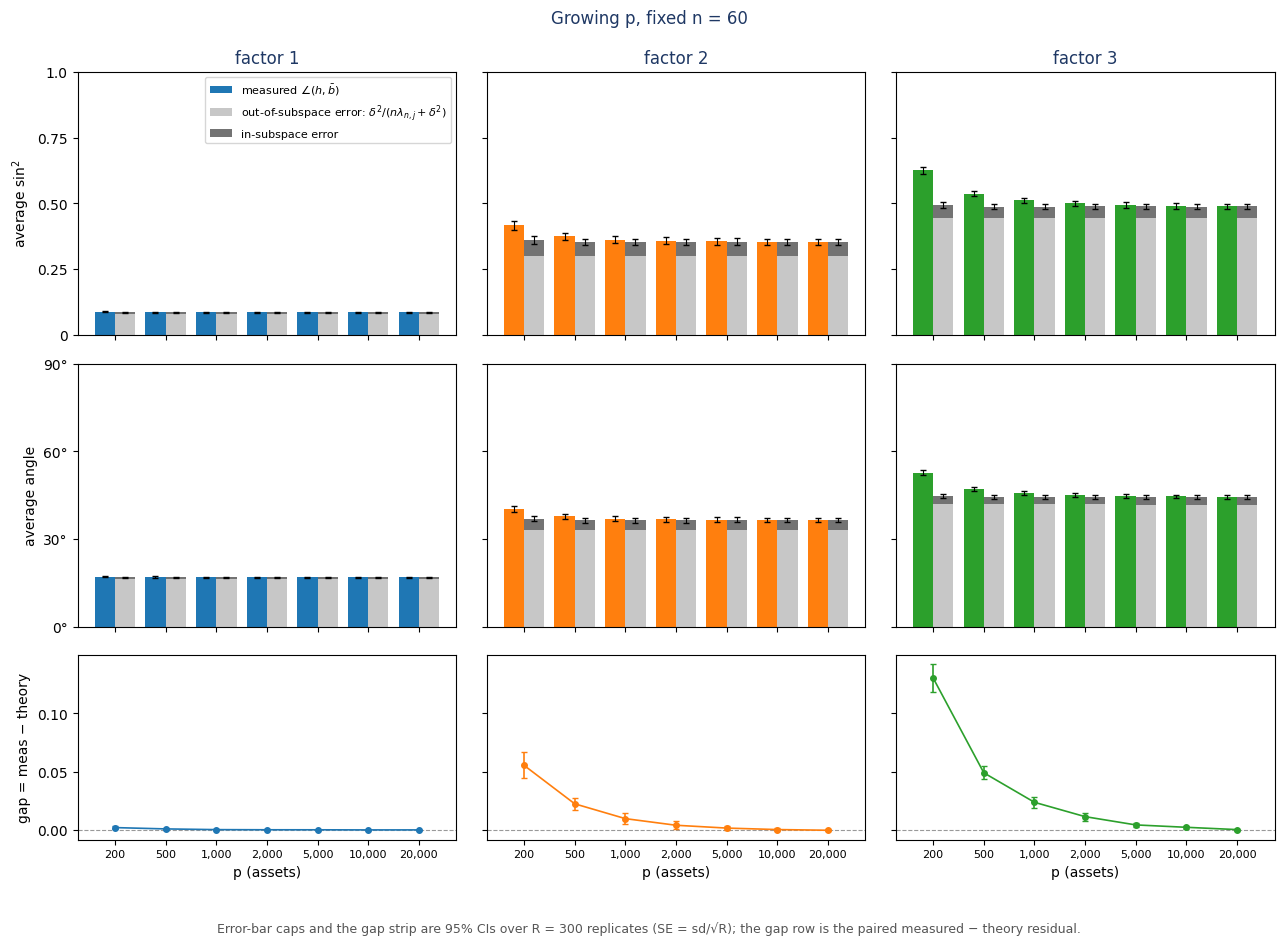

In [4]:
# Growing p, fixed n: Eq. (17) decomposition in two frames + a residual strip.
# Rows: sin^2 (additive) | angle | gap = measured - theory (sin^2). Bars: measured
# beside theory stacked as oos + in-subspace; caps / strip = 95% CI (R = 300).
fig, axes = plt.subplots(3, 3, figsize=(13.3, 9.6), sharex="col", sharey="row",
                         gridspec_kw={"height_ratios": [1, 1, 0.7]})
fig.subplots_adjust(left=0.07, right=0.97, top=0.92, bottom=0.12, hspace=0.12, wspace=0.08)
cats = [f"{p:,}" for p in P_VALUES]
for j in (1, 2, 3):
    a = avg[avg["j"] == j].set_index("p").loc[P_VALUES]
    decomp_panel(axes[0, j-1], cats, a["s2_meas"].to_numpy(), a["s2_oos"].to_numpy(),
                 (a["s2_theory"] - a["s2_oos"]).to_numpy(), FACTOR_COLORS[j-1],
                 meas_se=a["s2_meas_se"].to_numpy(), total_se=a["s2_theory_se"].to_numpy())
    axes[0, j-1].set_title(f"factor {j}", color=NAVY)
    decomp_panel(axes[1, j-1], cats, a["ang_meas"].to_numpy(), a["ang_oos"].to_numpy(),
                 (a["ang_theory"] - a["ang_oos"]).to_numpy(), FACTOR_COLORS[j-1],
                 meas_se=a["ang_meas_se"].to_numpy(), total_se=a["ang_theory_se"].to_numpy())
    gap_panel(axes[2, j-1], cats, a["gap"].to_numpy(), a["gap_se"].to_numpy(), FACTOR_COLORS[j-1])
    axes[2, j-1].set_xlabel("p (assets)")
axes[0, 0].set_ylim(0, 1);  axes[0, 0].set_yticks(*SIN2_TICKS); axes[0, 0].set_ylabel(r"average $\sin^2$")
axes[1, 0].set_ylim(0, 90); axes[1, 0].set_yticks(*DEG_TICKS);  axes[1, 0].set_ylabel("average angle")
axes[2, 0].set_ylabel("gap = meas − theory")
axes[0, 0].legend(fontsize=8, loc="upper right")
for ax in axes.flat:
    ax.label_outer()
fig.suptitle(f"Growing p, fixed n = {N_FIXED}", color=NAVY, y=0.985)
fig.text(0.5, 0.035, "Error-bar caps and the gap strip are 95% CIs over R = 300 replicates "
         "(SE = sd/√R); the gap row is the paired measured − theory residual.",
         ha="center", va="top", fontsize=9, color=GRAY)
plt.show()

replicate:   0%|          | 0/300 [00:00<?, ?rep/s]

replicate:   2%|▏         | 6/300 [00:00<00:05, 52.83rep/s]

replicate:   4%|▍         | 12/300 [00:00<00:05, 55.35rep/s]

replicate:   6%|▌         | 18/300 [00:00<00:05, 55.96rep/s]

replicate:   8%|▊         | 24/300 [00:00<00:04, 56.40rep/s]

...

replicate:  94%|█████████▍| 282/300 [00:04<00:00, 57.28rep/s]

replicate:  96%|█████████▌| 288/300 [00:05<00:00, 57.26rep/s]

replicate:  98%|█████████▊| 294/300 [00:05<00:00, 56.43rep/s]

replicate: 100%|██████████| 300/300 [00:05<00:00, 55.83rep/s]

replicate: 100%|██████████| 300/300 [00:05<00:00, 56.87rep/s]

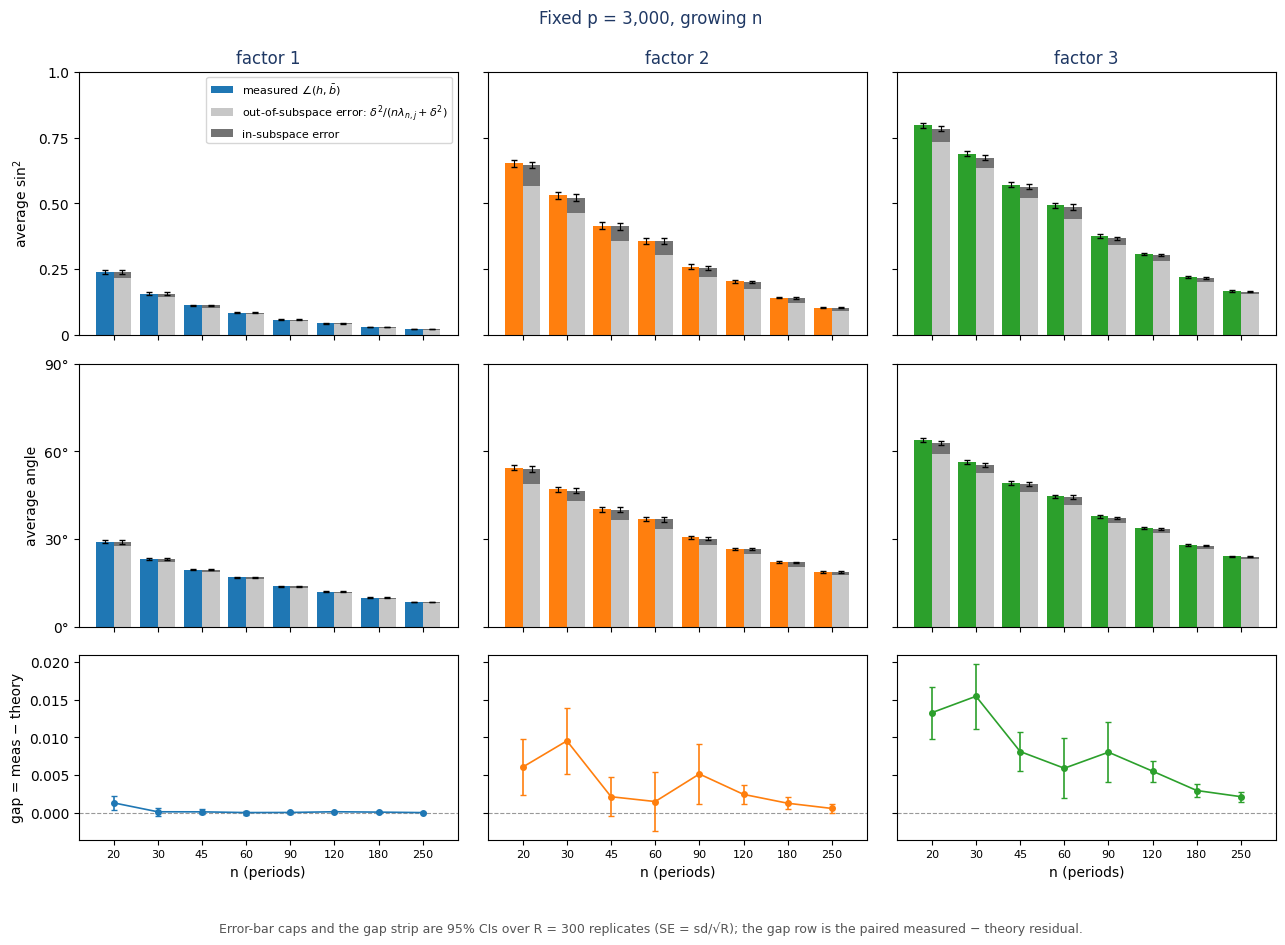

In [5]:
# Fixed p = 3000, growing n: same three-frame view (sin^2 additive | angle | gap).
P_FIXED = 3000
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 90, 120, 180, 250],
    p_values=[P_FIXED],
    n_reps=300,
    random_seed=20260511,
    sampling="nested",
)
df_n = run_experiment(model, design_n, DispersionBiasExperiment())
d_n = df_n.assign(
    s2_meas=df_n["sin2_j"], s2_theory=df_n["rhs"], s2_oos=df_n["floor"],
    ang_meas=to_deg(df_n["sin2_j"]), ang_theory=to_deg(df_n["rhs"]), ang_oos=to_deg(df_n["floor"]),
)
avg_n = summarize(d_n, "n")
N_VALUES = sorted(d_n["n"].unique())
fig, axes = plt.subplots(3, 3, figsize=(13.3, 9.6), sharex="col", sharey="row",
                         gridspec_kw={"height_ratios": [1, 1, 0.7]})
fig.subplots_adjust(left=0.07, right=0.97, top=0.92, bottom=0.12, hspace=0.12, wspace=0.08)
cats = [str(n) for n in N_VALUES]
for j in (1, 2, 3):
    a = avg_n[avg_n["j"] == j].set_index("n").loc[N_VALUES]
    decomp_panel(axes[0, j-1], cats, a["s2_meas"].to_numpy(), a["s2_oos"].to_numpy(),
                 (a["s2_theory"] - a["s2_oos"]).to_numpy(), FACTOR_COLORS[j-1],
                 meas_se=a["s2_meas_se"].to_numpy(), total_se=a["s2_theory_se"].to_numpy())
    axes[0, j-1].set_title(f"factor {j}", color=NAVY)
    decomp_panel(axes[1, j-1], cats, a["ang_meas"].to_numpy(), a["ang_oos"].to_numpy(),
                 (a["ang_theory"] - a["ang_oos"]).to_numpy(), FACTOR_COLORS[j-1],
                 meas_se=a["ang_meas_se"].to_numpy(), total_se=a["ang_theory_se"].to_numpy())
    gap_panel(axes[2, j-1], cats, a["gap"].to_numpy(), a["gap_se"].to_numpy(), FACTOR_COLORS[j-1])
    axes[2, j-1].set_xlabel("n (periods)")
axes[0, 0].set_ylim(0, 1);  axes[0, 0].set_yticks(*SIN2_TICKS); axes[0, 0].set_ylabel(r"average $\sin^2$")
axes[1, 0].set_ylim(0, 90); axes[1, 0].set_yticks(*DEG_TICKS);  axes[1, 0].set_ylabel("average angle")
axes[2, 0].set_ylabel("gap = meas − theory")
axes[0, 0].legend(fontsize=8, loc="upper right")
for ax in axes.flat:
    ax.label_outer()
fig.suptitle(f"Fixed p = {P_FIXED:,}, growing n", color=NAVY, y=0.985)
fig.text(0.5, 0.035, "Error-bar caps and the gap strip are 95% CIs over R = 300 replicates "
         "(SE = sd/√R); the gap row is the paired measured − theory residual.",
         ha="center", va="top", fontsize=9, color=GRAY)
plt.show()

replicate:   0%|          | 0/300 [00:00<?, ?rep/s]

replicate:   3%|▎         | 9/300 [00:00<00:03, 84.08rep/s]

replicate:   6%|▌         | 18/300 [00:00<00:03, 86.22rep/s]

replicate:   9%|▉         | 27/300 [00:00<00:03, 87.10rep/s]

replicate:  12%|█▏        | 36/300 [00:00<00:03, 87.71rep/s]

...

replicate:  90%|█████████ | 270/300 [00:03<00:00, 88.38rep/s]

replicate:  93%|█████████▎| 279/300 [00:03<00:00, 88.61rep/s]

replicate:  96%|█████████▌| 288/300 [00:03<00:00, 88.66rep/s]

replicate:  99%|█████████▉| 297/300 [00:03<00:00, 88.78rep/s]

replicate: 100%|██████████| 300/300 [00:03<00:00, 88.33rep/s]

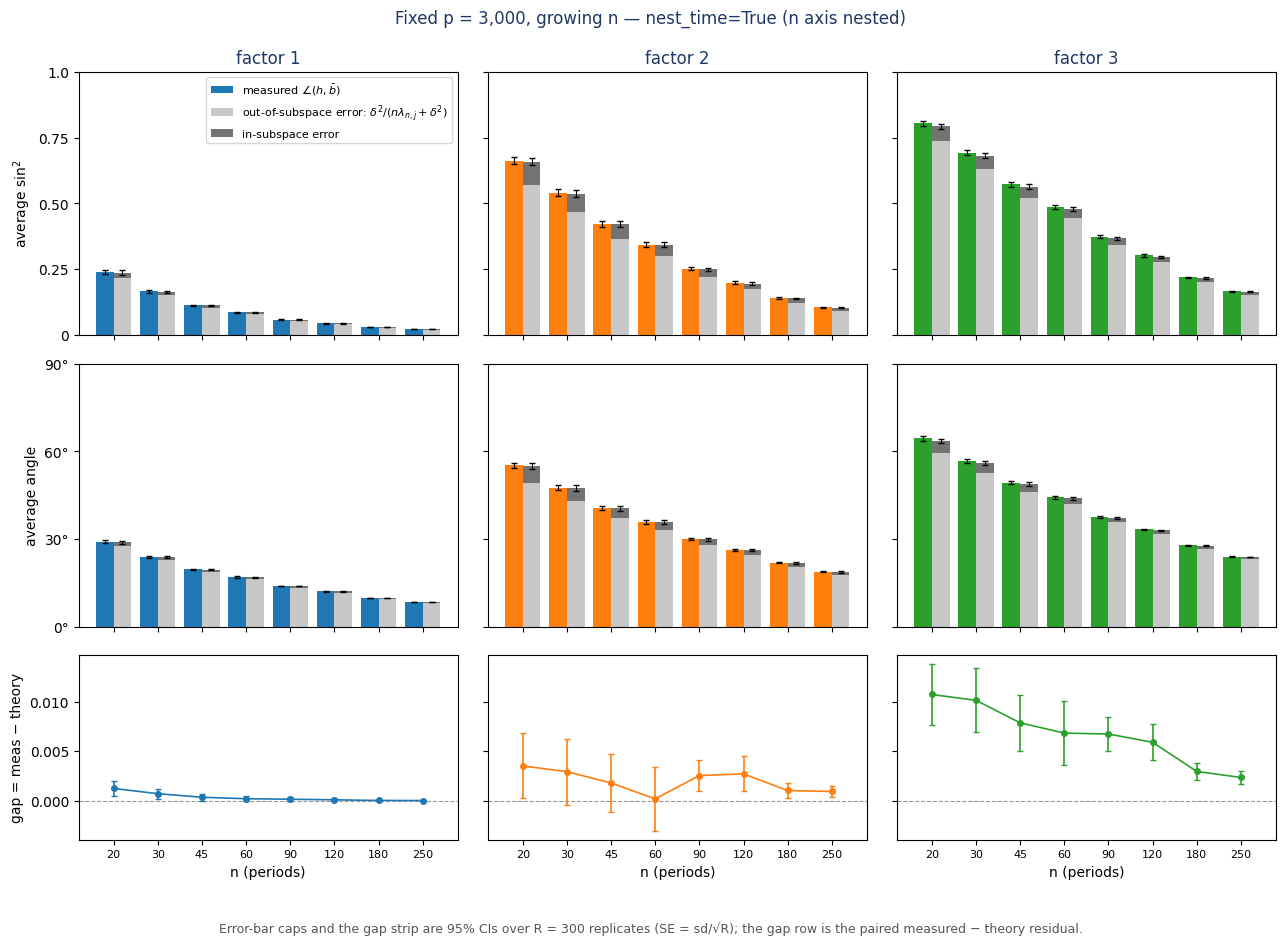

In [6]:
# Same fixed-p = 3000 sweep with nest_time=True (n axis nested): smoother n-curve.
P_FIXED = 3000
design_nt = DesignSpec(
    n_values=[20, 30, 45, 60, 90, 120, 180, 250],
    p_values=[P_FIXED],
    n_reps=300,
    random_seed=20260511,
    sampling="nested",
    nest_time=True,
)
df_nt = run_experiment(model, design_nt, DispersionBiasExperiment())
d_nt = df_nt.assign(
    s2_meas=df_nt["sin2_j"], s2_theory=df_nt["rhs"], s2_oos=df_nt["floor"],
    ang_meas=to_deg(df_nt["sin2_j"]), ang_theory=to_deg(df_nt["rhs"]), ang_oos=to_deg(df_nt["floor"]),
)
avg_nt = summarize(d_nt, "n")
N_VALUES_NT = sorted(d_nt["n"].unique())
fig, axes = plt.subplots(3, 3, figsize=(13.3, 9.6), sharex="col", sharey="row",
                         gridspec_kw={"height_ratios": [1, 1, 0.7]})
fig.subplots_adjust(left=0.07, right=0.97, top=0.92, bottom=0.12, hspace=0.12, wspace=0.08)
cats = [str(n) for n in N_VALUES_NT]
for j in (1, 2, 3):
    a = avg_nt[avg_nt["j"] == j].set_index("n").loc[N_VALUES_NT]
    decomp_panel(axes[0, j-1], cats, a["s2_meas"].to_numpy(), a["s2_oos"].to_numpy(),
                 (a["s2_theory"] - a["s2_oos"]).to_numpy(), FACTOR_COLORS[j-1],
                 meas_se=a["s2_meas_se"].to_numpy(), total_se=a["s2_theory_se"].to_numpy())
    axes[0, j-1].set_title(f"factor {j}", color=NAVY)
    decomp_panel(axes[1, j-1], cats, a["ang_meas"].to_numpy(), a["ang_oos"].to_numpy(),
                 (a["ang_theory"] - a["ang_oos"]).to_numpy(), FACTOR_COLORS[j-1],
                 meas_se=a["ang_meas_se"].to_numpy(), total_se=a["ang_theory_se"].to_numpy())
    gap_panel(axes[2, j-1], cats, a["gap"].to_numpy(), a["gap_se"].to_numpy(), FACTOR_COLORS[j-1])
    axes[2, j-1].set_xlabel("n (periods)")
axes[0, 0].set_ylim(0, 1);  axes[0, 0].set_yticks(*SIN2_TICKS); axes[0, 0].set_ylabel(r"average $\sin^2$")
axes[1, 0].set_ylim(0, 90); axes[1, 0].set_yticks(*DEG_TICKS);  axes[1, 0].set_ylabel("average angle")
axes[2, 0].set_ylabel("gap = meas − theory")
axes[0, 0].legend(fontsize=8, loc="upper right")
for ax in axes.flat:
    ax.label_outer()
fig.suptitle(f"Fixed p = {P_FIXED:,}, growing n — nest_time=True (n axis nested)", color=NAVY, y=0.985)
fig.text(0.5, 0.035, "Error-bar caps and the gap strip are 95% CIs over R = 300 replicates "
         "(SE = sd/√R); the gap row is the paired measured − theory residual.",
         ha="center", va="top", fontsize=9, color=GRAY)
plt.show()